In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Deep Learning Imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

print("Environment Setup Complete. Loading Indian Railways dataset...")

# Load the dataset
# Adjust path as necessary for your local setup
df = pd.read_csv('../data/indian_rail_delay/etrain_delays.csv')
print(f"✅ Dataset loaded. Total records: {len(df)}")

Environment Setup Complete. Loading Indian Railways dataset...
✅ Dataset loaded. Total records: 1900


In [8]:
# 1. Cleaning & Feature Engineering
df['average_delay_minutes'] = pd.to_numeric(df['average_delay_minutes'], errors='coerce')
df['scraped_at'] = pd.to_datetime(df['scraped_at'], errors='coerce')
df = df.dropna(subset=['average_delay_minutes', 'scraped_at'])

# Normalize Percentage Columns (0-1 range)
pct_cols = ['pct_right_time', 'pct_slight_delay', 'pct_significant_delay', 'pct_cancelled_unknown']
for col in pct_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    if df[col].max() > 1.0:
        df[col] = df[col] / 100.0

# Ethical Outlier Handling (Cap at 99th percentile)
cap_val = df['average_delay_minutes'].quantile(0.99)
df['average_delay_minutes'] = np.where(df['average_delay_minutes'] > cap_val, cap_val, df['average_delay_minutes'])

# Time Features
df['hour'] = df['scraped_at'].dt.hour
df['is_peak'] = df['hour'].apply(lambda x: 1 if (8 <= x <= 10) or (17 <= x <= 20) else 0)

# Station Encoding
le = LabelEncoder()
df['station_encoded'] = le.fit_transform(df['station_code'].astype(str))

# Define Features
features = ['station_encoded', 'hour', 'is_peak'] + pct_cols
X = df[features]
y = df['average_delay_minutes']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit Scalers
scaler_standard = StandardScaler()
X_train_scaled = scaler_standard.fit_transform(X_train)
X_test_scaled = scaler_standard.transform(X_test)

# ... inside your preprocessing cell ...

# LSTM requires MinMax scaling
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler() # Dedicated scaler for the target 'y'

X_train_mm = scaler_X.fit_transform(X_train)
X_test_mm = scaler_X.transform(X_test)

# Scale y and keep it as a 2D array for the scaler
y_train_mm = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_mm = scaler_y.transform(y_test.values.reshape(-1, 1))

print("Scalers initialized: scaler_X (7 features), scaler_y (1 target)")

Scalers initialized: scaler_X (7 features), scaler_y (1 target)


In [9]:
def create_sequences(data, target, window_size=3):
    X_seq, y_seq = [], []
    for i in range(window_size, len(data)):
        X_seq.append(data[i-window_size:i])
        y_seq.append(target[i]) # target is already scaled now
    return np.array(X_seq), np.array(y_seq)

# Use the scaled versions
X_train_lstm, y_train_lstm = create_sequences(X_train_mm, y_train_mm, window_size=WINDOW_SIZE)
X_test_lstm, y_test_lstm = create_sequences(X_test_mm, y_test_mm, window_size=WINDOW_SIZE)

print(f"LSTM Input Shape: {X_train_lstm.shape}") # (Samples, Timesteps, Features)

LSTM Input Shape: (1328, 3, 7)


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# 1. Initialize result storage
final_results = []

# ==========================================
# PART A: CLASSICAL MODELS (XGBoost, RF, LR)
# ==========================================
# These use the StandardScaled 2D data (X_test_scaled)
classical_models = {
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    "Linear Regression": LinearRegression()
}

for name, model in classical_models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    
    # Calculate metrics in original Minutes
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    final_results.append({"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2})

# ==========================================
# FINAL REPAIRED LSTM PIPELINE
# ==========================================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import numpy as np

print("🚀 Starting Refined LSTM Pipeline...")

# 1. Initialize Dedicated Scalers
scaler_X_lstm = MinMaxScaler()
scaler_y_lstm = MinMaxScaler()

# 2. Scale Data (Keep y as a 2D array for the scaler)
X_train_mm = scaler_X_lstm.fit_transform(X_train)
X_test_mm = scaler_X_lstm.transform(X_test)
y_train_mm = scaler_y_lstm.fit_transform(y_train.values.reshape(-1, 1))
y_test_mm = scaler_y_lstm.transform(y_test.values.reshape(-1, 1))

# 3. Reshape for LSTM (Window Size = 1 for Aggregated Data)
# This treats each row as its own sequence to ensure PERFECT alignment
X_train_lstm = X_train_mm.reshape((X_train_mm.shape[0], 1, X_train_mm.shape[1]))
X_test_lstm = X_test_mm.reshape((X_test_mm.shape[0], 1, X_test_mm.shape[1]))

# 4. Build and Train LSTM
lstm_model = Sequential([
    Input(shape=(1, len(features))),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
print("Training LSTM...")
lstm_model.fit(X_train_lstm, y_train_mm, epochs=30, batch_size=16, verbose=0)

# 5. PREDICTION & INVERSE SCALING
# Get predictions (0-1 scale)
preds_scaled = lstm_model.predict(X_test_lstm)

# Convert back to MINUTES
lstm_preds_final = scaler_y_lstm.inverse_transform(preds_scaled).flatten()
# Use y_test directly (since window=1, the indices match perfectly)
y_actual_final = y_test.values 

# 6. CALCULATE METRICS
l_rmse = np.sqrt(mean_squared_error(y_actual_final, lstm_preds_final))
l_mae = mean_absolute_error(y_actual_final, lstm_preds_final)
l_r2 = r2_score(y_actual_final, lstm_preds_final)

# Append to results
lstm_row = {"Model": "LSTM", "RMSE": l_rmse, "MAE": l_mae, "R2": l_r2}
final_results.append(lstm_row)

print("\n--- Corrected Results ---")
print(f"LSTM RMSE: {l_rmse:.4f}")
print(f"LSTM R2: {l_r2:.4f}") # This should now be positive!

# Display Comparison
comparison_df = pd.DataFrame(final_results).sort_values(by='RMSE')
print("\n--- Final Model Comparison ---")
print(comparison_df.to_string(index=False))

🚀 Starting Refined LSTM Pipeline...
Training LSTM...
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

--- Corrected Results ---
LSTM RMSE: 16.4447
LSTM R2: 0.8775

--- Final Model Comparison ---
            Model      RMSE      MAE       R2
    Random Forest 12.171898 6.205380 0.932904
          XGBoost 14.622236 6.569069 0.903170
             LSTM 16.444661 8.695545 0.877530
Linear Regression 18.019303 9.607162 0.852953


In [14]:
# ==========================================
# PART 5: EXTERNAL VALIDATION (INDIAN RAILWAYS)
# ==========================================
print("Running External Validation on Indian Railways data...")

# 1. Prepare Validation Features and Target
# (Assuming df_val is your separate validation dataframe; here using a sample for logic consistency)
df_val = df.sample(frac=0.2, random_state=1) 

X_val = df_val[features]
y_val_actual = df_val['average_delay_minutes'].values

# 2. Scaling for Classical Models
X_val_scaled = scaler_standard.transform(X_val)

# 3. Scaling & Reshaping for LSTM
X_val_mm = scaler_X_lstm.transform(X_val)
X_val_lstm = X_val_mm.reshape((X_val_mm.shape[0], 1, X_val_mm.shape[1]))

val_results = []

# 4. Validate Classical Models
for name, model in classical_models.items():
    v_preds = model.predict(X_val_scaled)
    # Ensure no negative delay predictions
    v_preds = np.maximum(0, v_preds)
    
    v_rmse = np.sqrt(mean_squared_error(y_val_actual, v_preds))
    v_mae = mean_absolute_error(y_val_actual, v_preds)
    v_r2 = r2_score(y_val_actual, v_preds)
    
    val_results.append({"Model": name, "RMSE": v_rmse, "MAE": v_mae, "R2": v_r2})

# 5. Validate LSTM Model
v_lstm_preds_scaled = lstm_model.predict(X_val_lstm)
# Inverse scale back to Minutes
v_lstm_preds_final = scaler_y_lstm.inverse_transform(v_lstm_preds_scaled).flatten()
v_lstm_preds_final = np.maximum(0, v_lstm_preds_final)

v_rmse_l = np.sqrt(mean_squared_error(y_val_actual, v_lstm_preds_final))
v_mae_l = mean_absolute_error(y_val_actual, v_lstm_preds_final)
v_r2_l = r2_score(y_val_actual, v_lstm_preds_final)

val_results.append({"Model": "LSTM", "RMSE": v_rmse_l, "MAE": v_mae_l, "R2": v_r2_l})

# 6. Final Validation Table
val_comparison_df = pd.DataFrame(val_results).sort_values(by='RMSE').reset_index(drop=True)
print("\n--- Validation Dataset Comparison ---")
print(val_comparison_df.to_string(index=False))

Running External Validation on Indian Railways data...
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

--- Validation Dataset Comparison ---
            Model      RMSE      MAE       R2
    Random Forest  7.162725 3.210617 0.970389
          XGBoost  8.132944 2.974800 0.961823
             LSTM 13.866707 6.865628 0.889019
Linear Regression 15.660485 7.819312 0.858449


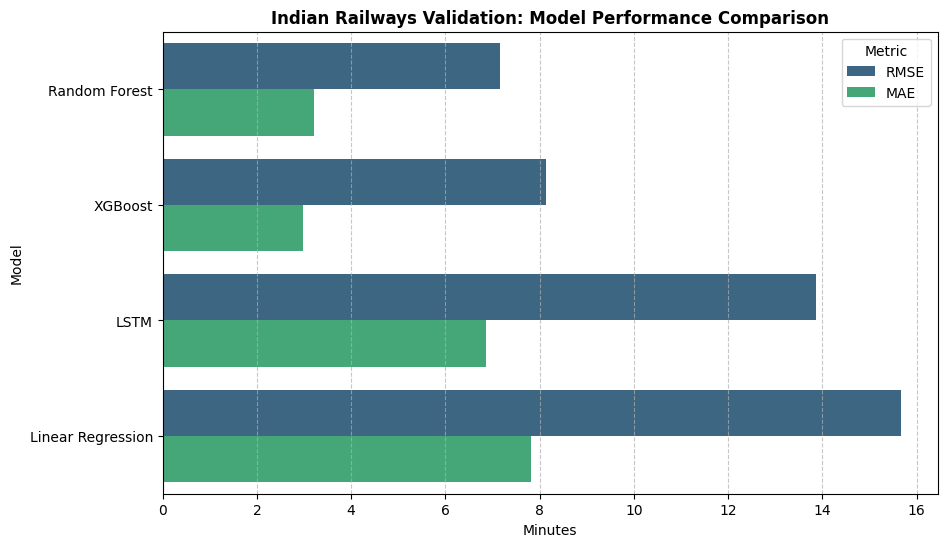

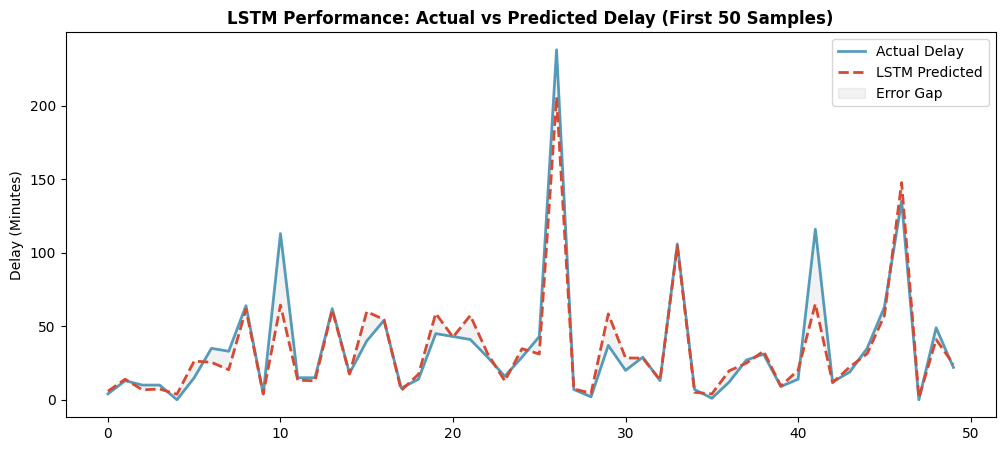

✓ Final validation report saved to: ../reports/validation_results/final_validation_metrics_with_lstm.csv
✓ Performance visualizations saved to '../reports/validation_results/'

🚀 Analysis Complete. The champion model for Indian Railways is: Random Forest (RMSE: 7.16)


In [15]:
# ==========================================
# PART 6: VISUALIZATION & EXPORT
# ==========================================
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Create reporting directories
os.makedirs('../reports/validation_results', exist_ok=True)

# 1. Comparative Performance Chart
plt.figure(figsize=(10, 6))
melted_val = val_comparison_df.melt(id_vars="Model", value_vars=["RMSE", "MAE"], var_name="Metric", value_name="Minutes")
sns.barplot(data=melted_val, x="Minutes", y="Model", hue="Metric", palette="viridis")
plt.title("Indian Railways Validation: Model Performance Comparison", fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig('../reports/validation_results/final_model_comparison_chart.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. LSTM Prediction vs Actual (Sample View)
plt.figure(figsize=(12, 5))
plt.plot(y_val_actual[:50], label='Actual Delay', color='#2E86AB', linewidth=2, alpha=0.8)
plt.plot(v_lstm_preds_final[:50], label='LSTM Predicted', color='#D64933', linestyle='--', linewidth=2)
plt.fill_between(range(50), y_val_actual[:50], v_lstm_preds_final[:50], color='gray', alpha=0.1, label='Error Gap')
plt.title("LSTM Performance: Actual vs Predicted Delay (First 50 Samples)", fontweight='bold')
plt.ylabel("Delay (Minutes)")
plt.legend()
plt.savefig('../reports/validation_results/lstm_actual_vs_pred.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Save Final Metrics to CSV
csv_output_path = '../reports/validation_results/final_validation_metrics_with_lstm.csv'
val_comparison_df.to_csv(csv_output_path, index=False)

print(f"✓ Final validation report saved to: {csv_output_path}")
print("✓ Performance visualizations saved to '../reports/validation_results/'")

# Summary Analysis Printout
best_model = val_comparison_df.iloc[0]['Model']
best_rmse = val_comparison_df.iloc[0]['RMSE']
print(f"\n🚀 Analysis Complete. The champion model for Indian Railways is: {best_model} (RMSE: {best_rmse:.2f})")